# Criteo Uplift Modeling: Individual Treatment Effect Estimation

**Single entry point.** Attach a Kaggle dataset containing `criteo-uplift-v2.1.csv`,
set `RUN_STAGE` below, then Run All. Every model, transform, and metric is
imported from `src/`; nothing is reimplemented in this notebook.

## The problem

An advertiser wants to know: *for which users does showing an ad actually
change their behaviour?* A response model answers a different, easier
question -- *who is likely to convert regardless* -- and targeting on it
wastes budget on users who would have converted anyway. **Uplift modeling**
instead estimates the **conditional average treatment effect (CATE)**,
`tau(x) = E[Y(1) - Y(0) | X = x]` -- `Y(1)`/`Y(0)` are the outcome a user
would have shown under treatment / control, only one of which is ever
observed -- so users can be ranked by the *incremental* effect of
treatment, not by their baseline propensity to convert.

## Objective

Compare four estimators of increasing sophistication on **CRITEO-UPLIFTv2.1**
(~13.9M rows, a real advertising A/B test) and report which ranks users by
incremental conversion most effectively, under an evaluation protocol that
never lets a model touch the data it is ultimately scored on:

| Model | Idea | What this buys you |
|---|---|---|
| **Response model** (LightGBM) | Non-causal comparator: predicts `P(Y\|X)`, ignores treatment entirely | Shows what a "target likely converters" strategy looks like -- the thing every uplift model below has to beat to earn its extra complexity |
| **T-Learner** | Two independent outcome models, one per arm; `tau_hat = mu1_hat - mu0_hat` | The simplest way to estimate *incremental* effect: model each arm separately, then subtract |
| **X-Learner** | Cross-fitted pseudo-outcome regression; corrects the T-Learner's imbalanced-arm bias | Same goal as T-Learner, but corrects for treatment/control being different sizes here, which otherwise biases the T-Learner's estimate |
| **Causal Forest** (`econml.grf.CausalForest`) | Honest random forest that splits directly on treatment-effect heterogeneity | Estimates the effect directly, growing trees whose splits are chosen to separate users with different effects, rather than differencing two separately-fit models |

`Y` above is whichever outcome this run selects -- `conversion` by default,
or `visit` (see **Run parameters** below).

## Evaluation

- **Qini curve / Qini above random** -- primary ranking statistic
- **AUUC** (area under the uplift curve) -- a differently-weighted second view
- **Uplift@K** and a **decile breakdown** -- coarser, more interpretable slices
- **CATE distribution** -- is the model finding real heterogeneity, or a near-constant effect?

(See **"How to read this notebook"**, right after Run parameters below, for
plain-language definitions of every term above.)

See `README.md`'s "Methodology notes" for the modeling decisions that matter
(D32 categorical handling, X-Learner fold-local preprocessing, Causal Forest
categorical encoding) and the four development notebooks for the full
derivation of each estimator:

| Notebook | Covers |
|---|---|
| `01_data_processing` | data contract, feature semantics, the split |
| `02_baseline_models` | response model, and why it is *not* a causal estimator |
| `03_uplift_models` | T-Learner, X-Learner, the fold-local leakage fix |
| `04_causal_forest` | Causal Forest, categorical encoding, final comparison |

## Why this notebook runs as stages, not one long script

`econml`'s `CausalForest` one-hot-encodes categorical features into a dense
matrix (~76 columns at the shipped `K=8`); at full CRITEO scale that matrix
alone is several GB, on top of the LightGBM-transformed matrices the other
three models use. Holding all of it in one kernel at once is a real OOM risk
on a standard Kaggle kernel. This notebook instead runs as **independent,
restart-safe stages** -- each stage loads only what it needs, saves its
expensive output as an artifact under `outputs/` (shared stages) or
`outputs/{outcome}/...` (model stages), and releases memory (`del` +
`gc.collect()`) before the next stage. Run All in
one session, or restart the kernel between stages (Data -> Baseline -> Uplift
-> Causal Forest -> Report) -- each stage picks up from the artifacts the
previous one saved, so nothing is retrained unnecessarily.


## Run parameters

- **`RUN_STAGE`** selects what to (re)compute this run. Every stage other than
  `"data"` first calls `ensure_data_artifacts()`, which loads existing data
  artifacts if they match the current `SAMPLE_ROWS`/`SEED`, or (re)computes
  them if missing or stale -- so `RUN_STAGE = "uplift"` alone works even on a
  fresh kernel, it just costs one data pass.

  | Value | Runs |
  |---|---|
  | `"data"` | data load, split, dataset/feature EDA |
  | `"baseline"` | response model |
  | `"uplift"` | T-Learner, X-Learner |
  | `"causal_forest"` | Causal Forest (the slow stage) |
  | `"report"` | final comparison + every visualization, **from artifacts only** -- fits nothing, so it is the stage to run after a kernel restart to see results without retraining |
  | `"all"` | every stage above, in order, in one session |
- **`SAMPLE_ROWS = None`** runs the complete ~13.9M-row experiment. Set e.g.
  `SAMPLE_ROWS = 1_000_000` for a fast end-to-end check first -- the sample is
  stratified on `(treatment, conversion)`, and every model sees the same rows.
- **`OUTCOME = "conversion"`** (default) or `"visit"` selects which column every
  model stage reads as `Y` (see `src.data.resolve_outcome`). `conversion` is the
  primary, business-oriented experiment; `visit` is a secondary sensitivity
  analysis on the exact same row partition -- see the outcome comparison in
  Stage 1 for why. Model, evaluation, and baseline/uplift/causal_forest/report
  artifacts are kept in separate `outputs/{outcome}/...` subtrees so the two
  never collide; `outputs/data/` and `outputs/preprocessing/` are shared, since
  neither depends on which outcome is selected.
- **`RUN_CAUSAL_FOREST = True`**: the Causal Forest is the bottleneck
  (`econml`'s `CausalForest` runs with `n_jobs=1`, required for reproducible
  predictions, so a full-data fit can take hours). Set `False` to skip it --
  the report stage still shows every other model and marks Causal Forest as
  pending rather than fabricate a result.

In [1]:
RUN_STAGE = "all"          # "data" | "baseline" | "uplift" | "causal_forest" | "report" | "all"
SAMPLE_ROWS = None          # None = full dataset; e.g. 1_000_000 for a fast run
SEED = 42
OUTCOME = "visit"      # "conversion" (primary) | "visit" (secondary sensitivity analysis --
                             # see docs/secondary_visit_outcome_experiment_plan.md). Resolved and
                             # validated just below, once resolve_outcome is imported.
RUN_CAUSAL_FOREST = True    # set False to skip the slowest stage

# DEBUG controls how much execution/infrastructure detail this notebook
# prints -- repository paths, dependency versions, cache/artifact
# filesystem paths, internal stage diagnostics. It never changes what is
# computed, only what is printed: every scientific output (dataset
# statistics, model comparisons, Qini/AUUC results, findings) is always
# shown regardless of this flag. Set True for troubleshooting on Kaggle.
DEBUG = False


def debug_print(*args, **kwargs) -> None:
    if DEBUG:
        print(*args, **kwargs)


_VALID_STAGES = ("data", "baseline", "uplift", "causal_forest", "report", "all")
assert RUN_STAGE in _VALID_STAGES, f"RUN_STAGE={RUN_STAGE!r} must be one of {_VALID_STAGES}"


## How to read this notebook

A few terms recur throughout -- plain-language first, technical detail second.

- **Treatment / control.** Users were randomly split into two groups: the
  **treatment** group was shown an ad, the **control** group was not (or saw
  a placeholder). Comparing the two groups' behaviour is what makes any
  causal claim below possible at all.
- **Uplift.** How much *more* likely a user is to convert *because* they were
  shown the ad, compared with what they would have done anyway. This is
  different from "how likely is this user to convert" -- a user can be very
  likely to convert either way, in which case showing them an ad changes
  nothing.
- **CATE** (conditional average treatment effect). The formal name for
  "predicted uplift for a user with these specific characteristics." Every
  uplift model below is, underneath, a way of estimating this number per
  user.
- **Qini curve / Qini above random.** Sort users by predicted uplift, target
  the top slice, and ask: how many *extra* conversions did that targeting
  actually capture, compared with targeting the same number of users at
  random? The Qini curve plots that gain as the targeted slice widens from 0%
  to 100% of users; **Qini above random** is the single number this notebook
  leans on most to rank models -- how much better than random targeting a
  model's ranking is, in total.
- **AUUC** (area under the uplift curve). A second view of the same idea,
  computed slightly differently (see `src/evaluation.py`'s module docstring
  for the exact formula). Reported alongside Qini as a cross-check -- if both
  metrics agree on a model ranking, that ranking is more trustworthy.
- **uplift@K.** A more concrete, business-facing slice of the same idea:
  "if you only had budget to target the top K% of users by predicted uplift,
  how much extra conversion would you actually get?"
- **Honest causal forest.** A random forest where each tree splits on one
  random subsample of the data but *estimates* its leaf effects on a
  different, disjoint subsample. This is what stops the forest from choosing
  splits that flatter its own effect estimates -- without it, a tree could
  cherry-pick a split that looks good only because it was fit and graded on
  the same rows.
- **Paired bootstrap / confidence interval.** A way of asking "is this gap
  between two models real, or could it just be luck of the draw on this
  particular test set?" The test set is resampled (with replacement) many
  times, the metric gap is recomputed each time, and the middle 95% of those
  resampled gaps is the **95% confidence interval**. If that interval never
  crosses zero, the gap is unlikely to be noise; if it does cross zero, the
  data cannot rule out "no real difference."

Every model-fitting cell below is a short call into `src/` -- the modeling,
evaluation, and artifact-caching code lives there, not in this notebook, so
what you read here is the experiment's logic, not its plumbing.


## Stage 0 -- Environment validation

Always runs, regardless of `RUN_STAGE`: locate the repository (this notebook
does not assume the kernel's working directory), make `src/` importable, and
verify every dependency actually imports before any expensive work starts.

*(Infrastructure, not analysis -- safe to collapse and skip ahead to Stage 1
if you trust it works.)*


In [2]:
import sys, platform, subprocess
from pathlib import Path

# This cell must stay runnable standalone (tests/test_notebook_bootstrap.py
# execs it before DEBUG exists), so DEBUG is read defensively here rather
# than assumed already defined -- in a real notebook run it picks up
# whatever the run-parameters cell set; standalone, it defaults to False.
DEBUG = globals().get("DEBUG", False)


def debug_print(*args, **kwargs) -> None:
    if DEBUG:
        print(*args, **kwargs)


# A repo copy is only trusted if it has every module the notebook actually
# imports from -- src/data.py alone is not enough: a stale/incomplete repo
# copy (e.g. an interrupted clone from an earlier kernel run) can still have
# that one file while missing src/notebook_setup.py, src/pipeline.py, or
# src/reporting.py, which then fails as a confusing ModuleNotFoundError two
# cells later instead of here, where the actual problem is.
REQUIRED_MARKERS = (
    "src/data.py",
    "src/models.py",
    "src/preprocessing.py",
    "src/notebook_setup.py",
    "src/pipeline.py",
    "src/reporting.py",
)


def is_valid_repo_root(path: Path) -> bool:
    return all((path / marker).is_file() for marker in REQUIRED_MARKERS)


def find_repo_root() -> Path:
    bases = [Path.cwd(), *Path.cwd().parents, Path("/kaggle/working"), Path("/kaggle/input")]
    for base in bases:
        if not base.is_dir():
            continue
        if is_valid_repo_root(base):
            return base
        for child in sorted(p for p in base.iterdir() if p.is_dir()):
            if is_valid_repo_root(child):
                return child
    return None


REPO_ROOT = find_repo_root()

if REPO_ROOT is None and Path("/kaggle/working").is_dir():
    # Repo not attached -- try cloning it (requires Internet enabled in kernel settings).
    target = Path("/kaggle/working/causal-uplift-modeling")
    debug_print("Repository not found; attempting clone into", target)
    result = subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/arthur105204/causal-uplift-modeling.git", str(target)],
        capture_output=True, text=True,
    )
    debug_print(result.stdout or result.stderr)
    REPO_ROOT = find_repo_root()

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate the repository. Either attach it as a Kaggle dataset, "
        "clone it into /kaggle/working, or enable Internet in the kernel settings "
        "so this cell can clone it automatically."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

debug_print("python     :", platform.python_version())
debug_print("repo root  :", REPO_ROOT)
debug_print("\nRepository root:", REPO_ROOT)
debug_print("Required source files:")
for _marker in ("src/notebook_setup.py", "src/pipeline.py", "src/reporting.py"):
    _status = "OK" if (REPO_ROOT / _marker).is_file() else "MISSING"
    debug_print(f"  {_marker} {_status}")

try:
    _git_result = subprocess.run(
        ["git", "rev-parse", "--short", "HEAD"], cwd=REPO_ROOT,
        capture_output=True, text=True, timeout=5,
    )
    _commit = _git_result.stdout.strip() if _git_result.returncode == 0 and _git_result.stdout.strip() else None
except Exception:
    _commit = None
debug_print("git commit :", _commit if _commit else "git commit unavailable")

print("Repository validated.")


Repository validated.


In [3]:
from src.notebook_setup import check_dependencies

DEPENDENCY_VERSIONS = check_dependencies()
for name, version in DEPENDENCY_VERSIONS.items():
    debug_print(f"{name:12s} {version}")
print("Required dependencies available.")


Required dependencies available.


In [4]:
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Everything below comes from src/ -- no model code is defined in this notebook.
from src.data import (
    CATEGORICAL_FEATURES, CONTINUOUS_FEATURES, FEATURE_COLUMNS,
    PRIMARY_OUTCOME, SECONDARY_OUTCOME, TREATMENT_COLUMN,
    basic_summary, load_config, load_csv, load_parquet, on_kaggle,
    resolve_csv_path, resolve_outcome, save_parquet,
)
from src.preprocessing import (
    CausalForestCategoricalEncoder, LightGBMFeatureTransform, train_validation_test_split,
)
# fit_t_learner / fit_x_learner are called directly below (Stage 3) -- that
# call site is a deliberate guardrail, see Stage 3's markdown. The rest
# (fit_response_model, fit_causal_forest, predict, predict_causal_forest_tau)
# are called inside src.pipeline's stage runners now, and stay imported here
# too so this cell keeps naming every modelling primitive the notebook
# orchestrates, wherever the call itself actually happens.
from src.models import (
    fit_causal_forest, fit_response_model, fit_t_learner, fit_x_learner,
    predict, predict_causal_forest_tau,
)
from src.evaluation import compute_ate, evaluate_ranking, response_diagnostics
from src.artifacts import (
    artifact_is_fresh, artifact_root, config_fingerprint, experiment_metadata,
    load_csv_artifact, load_json, load_pickle, save_csv, save_json, save_pickle, stage_dir,
)
from src.pipeline import (
    get_lgbm_transform, run_baseline_stage, run_causal_forest_stage, run_data_stage, stage_cache_hit,
)
from src.reporting import (
    build_model_comparison_table, load_ranking_artifact, package_ranking_artifacts, paired_bootstrap_gaps,
)

CONFIG = load_config()
ARTIFACT_ROOT = artifact_root()
OUTCOME_COLUMN = resolve_outcome(OUTCOME)  # fails fast here if OUTCOME is misconfigured
debug_print("on kaggle     :", on_kaggle())
debug_print("artifact root :", ARTIFACT_ROOT)
debug_print("imports OK")
print(f"Environment ready. Modeling outcome: {OUTCOME_COLUMN}")


Environment ready. Modeling outcome: visit


In [5]:
from src.notebook_setup import collect_env_info

ENV_INFO = collect_env_info(
    REPO_ROOT, seed=SEED, sample_rows=SAMPLE_ROWS, run_stage=RUN_STAGE, outcome_column=OUTCOME_COLUMN,
)
for key, value in ENV_INFO.items():
    debug_print(f"{key:15s}: {value}")


## Stage 1 -- Data processing

Loads the raw CSV (auto-discovering the attached Kaggle dataset slug),
verifies the causal contract (`X = f0..f11`, `T = treatment`, `Y = conversion` by
default or `visit` when `OUTCOME = "visit"`),
computes the population ATE, optionally subsamples, and produces the seeded
70/15/15 train/validation/test split every later stage reads.

**Feature semantics (D32).** All twelve `f0`-`f11` columns are stored as
`float64`, but physical storage does not imply semantic type: `f0`, `f2`,
`f7`, `f10` are genuinely **continuous**; `f1`, `f3`, `f4`, `f5`, `f6`, `f8`,
`f9`, `f11` are **categorical numeric tokens** with no ordinal meaning.
`exposure` is post-assignment and is loaded only for the contract check --
never as a feature.

**Artifacts written** under `outputs/data/`: `dataset_summary.json`,
`feature_summary.csv`, `split_summary.json`, `run_config.json`, and
`train.parquet` / `validation.parquet` / `test.parquet` (the raw, unencoded
splits every other stage reads instead of re-parsing the CSV). Every other
stage calls `ensure_data_artifacts()` first and reuses these unchanged if
they match the current `SAMPLE_ROWS`/`SEED` -- this split is computed once,
stratified on `(treatment, conversion)`, and reused **unchanged** regardless of
which `OUTCOME` a run selects: both `conversion` and `visit` are already
present in every saved partition (see the outcome comparison below), so
switching outcomes only changes which column is read as `Y`, never the rows.

In [6]:
DATA_SIGNATURE = run_data_stage(CONFIG, SAMPLE_ROWS, SEED, ENV_INFO)
debug_print(f"Data stage ready -- artifacts under {stage_dir('data')}")


In [7]:
if RUN_STAGE in ("data", "all"):
    data_dir = stage_dir("data")
    dataset_summary = load_json(data_dir / "dataset_summary.json")
    split_summary = load_json(data_dir / "split_summary.json")

    summary_table = pd.DataFrame({
        "rows": {k: v["n_rows"] for k, v in split_summary.items()},
        "treatment_rate": {k: v["treatment_rate"] for k, v in split_summary.items()},
        "conversion_rate": {k: v["conversion_rate"] for k, v in split_summary.items()},
        "visit_rate": {k: v["visit_rate"] for k, v in split_summary.items()},
    })
    print(f"Rows (full)  : {dataset_summary['n_rows']:,}")
    print(f"Features     : {dataset_summary['n_features']} "
          f"({len(dataset_summary['continuous_features'])} continuous, "
          f"{len(dataset_summary['categorical_features'])} categorical)")
    print(f"Treatment    : {dataset_summary['treatment_counts']}")
    print(f"Conversion   : {dataset_summary['conversion_rate']:.5f} overall  "
          f"(treated {dataset_summary['conversion_rate_by_treatment'].get('1', float('nan')):.5f} / "
          f"control {dataset_summary['conversion_rate_by_treatment'].get('0', float('nan')):.5f})")
    print(f"Visit        : {dataset_summary['visit_rate']:.5f} overall")
    ate_info = dataset_summary["ate"]
    print(f"Population ATE : {ate_info['ate']:.6f}  (95% CI {ate_info['ci_95_low']:.6f} .. {ate_info['ci_95_high']:.6f})")
    display(summary_table.round(5))
else:
    print(f"Data EDA skipped (RUN_STAGE={RUN_STAGE!r}); artifacts still ensured above.")

Rows (full)  : 13,979,592
Features     : 12 (4 continuous, 8 categorical)
Treatment    : {'1': 11882655, '0': 2096937}
Conversion   : 0.00292 overall  (treated 0.00309 / control 0.00194)
Visit        : 0.04699 overall
Population ATE : 0.001152  (95% CI 0.001085 .. 0.001219)


,rows,treatment_rate,conversion_rate,visit_rate
train,9785714,0.85,0.00292,0.04706
validation,2096939,0.85,0.00292,0.04705
test,2096939,0.85,0.00292,0.04663


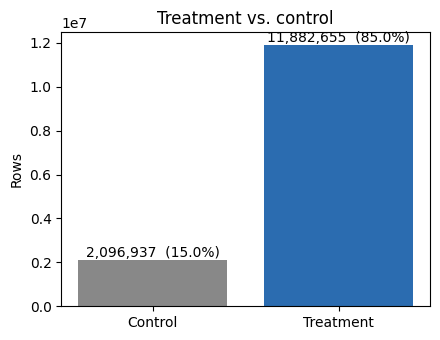

In [8]:
if RUN_STAGE in ("data", "all"):
    treated_n = dataset_summary["treatment_counts"].get("1", 0)
    control_n = dataset_summary["treatment_counts"].get("0", 0)
    total_n = treated_n + control_n
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    ax.bar(["Control", "Treatment"], [control_n, treated_n], color=["#888888", "#2b6cb0"])
    ax.set_ylabel("Rows")
    ax.set_title("Treatment vs. control")
    for i, v in enumerate([control_n, treated_n]):
        ax.text(i, v, f"{v:,}  ({v / total_n:.1%})", ha="center", va="bottom")
    fig.tight_layout()
    plt.show()


**Observation.** The treatment and control groups are not the same size --
see the percentages above.

**Interpretation.** This is expected and does not bias anything downstream:
assignment to treatment/control was randomized independently of group size,
so an unequal split still produces two comparable groups, just of different
counts. Every metric in this notebook (ATE, Qini, AUUC, uplift@K) is a
*rate* or *rate difference* comparison between the two arms, not a raw-count
comparison, so the imbalance itself carries no information -- it is a design
choice of the original experiment (e.g. holding out a smaller, cheaper
control group), not a data quality issue.

**Limitation.** A large imbalance does reduce the *effective sample size* of
the smaller arm, which is one reason confidence intervals later in this
notebook (the population ATE's CI, and the paired bootstrap in Stage 5) can
be wide even with millions of rows.


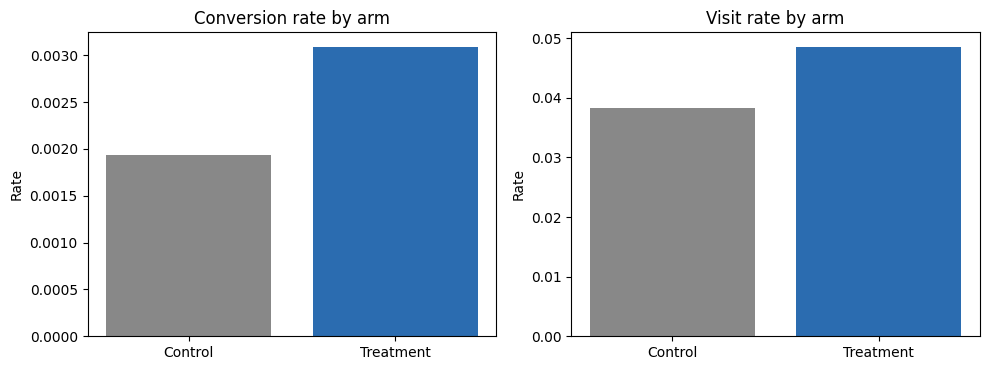

In [9]:
if RUN_STAGE in ("data", "all"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
    for ax, key, title in [
        (ax1, "conversion_rate_by_treatment", "Conversion rate by arm"),
        (ax2, "visit_rate_by_treatment", "Visit rate by arm"),
    ]:
        rates = dataset_summary[key]
        ax.bar(["Control", "Treatment"], [rates.get("0", 0.0), rates.get("1", 0.0)], color=["#888888", "#2b6cb0"])
        ax.set_title(title)
        ax.set_ylabel("Rate")
    fig.tight_layout()
    plt.show()

**Observation.** The treated group's conversion and visit rates are both
higher than control's -- consistent with the positive population ATE printed
above.

**Interpretation.** This confirms the treatment has a measurable, positive
average effect at the population level before any modeling happens. That is
necessary context for everything that follows: uplift modeling only becomes
interesting because this effect is *heterogeneous* -- some users respond
much more than others -- which the population-level bars above cannot show.

**Limitation.** A positive average effect does not imply every user
benefits; some may be unaffected or even respond negatively. Distinguishing
those users is exactly what Stage 3's uplift models attempt (see the CATE
distribution later in this notebook).


### Outcome comparison: conversion vs. visit

**Observation.** `conversion` -- the final, business-relevant action -- is
the outcome this project optimizes for, but it is a rare event. `visit` is
a much more common intermediate action on the same causal path (every
conversion is preceded by a visit; most visits do not convert). Same rows,
same treatment assignment, same causal question -- just a less sparse label
-- which is what makes it a natural secondary outcome for a sensitivity
analysis rather than an unrelated second experiment.

**Quantitative evidence.**

In [10]:
if RUN_STAGE in ("data", "all"):
    def _outcome_comparison_row(label, overall_rate, rate_by_treatment):
        treatment_rate = rate_by_treatment.get("1", float("nan"))
        control_rate = rate_by_treatment.get("0", float("nan"))
        return {
            "outcome": label,
            "overall_rate": overall_rate,
            "treatment_rate": treatment_rate,
            "control_rate": control_rate,
            "absolute_difference": treatment_rate - control_rate,
        }

    outcome_comparison = pd.DataFrame([
        _outcome_comparison_row(
            "conversion", dataset_summary["conversion_rate"], dataset_summary["conversion_rate_by_treatment"]
        ),
        _outcome_comparison_row(
            "visit", dataset_summary["visit_rate"], dataset_summary["visit_rate_by_treatment"]
        ),
    ]).set_index("outcome")

    prevalence_ratio = dataset_summary["visit_rate"] / dataset_summary["conversion_rate"]
    print(f"visit is {prevalence_ratio:.1f}x more prevalent than conversion in this dataset")
    print(f"this run's selected outcome (OUTCOME_COLUMN): {OUTCOME_COLUMN!r}")
    display(outcome_comparison.round(6))

visit is 16.1x more prevalent than conversion in this dataset
this run's selected outcome (OUTCOME_COLUMN): 'visit'


,overall_rate,treatment_rate,control_rate,absolute_difference
outcome,,,,
conversion,0.002917,0.003089,0.001938,0.001152
visit,0.046992,0.048543,0.038201,0.010342


**Modeling implication.** An outcome this sparse (`conversion`) means every
stage that estimates a treatment effect by differencing two outcome models
(T-Learner) or regressing an imputed pseudo-outcome (X-Learner) is working
with very few positive labels per arm -- estimation variance is driven by
how rare the event is, not by row count alone. `visit`'s much higher
prevalence gives the same estimators, unchanged, a denser signal to learn
from, which is precisely why comparing model rankings under both outcomes is
an informative check on whether a conclusion reached under `conversion` is a
real effect or an artifact of outcome sparsity.

**Interpretation.** `visit` does not replace `conversion` as the primary,
business-oriented experiment -- it runs in parallel, on the exact same
physical train/validation/test row partition (the split above is fit once,
stratified on `(treatment, conversion)`, and reused unchanged for both;
only which column is read as `Y` changes). Its results are reported
alongside `conversion`'s as a secondary sensitivity analysis, never as a
substitute conclusion.

### Feature analysis

Continuous features (`f0`, `f2`, `f7`, `f10`) and categorical numeric tokens
(`f1`, `f3`, `f4`, `f5`, `f6`, `f8`, `f9`, `f11`) get different diagnostics --
this project's internal shorthand for that continuous/categorical split is
"D32" (see README's Methodology notes), used elsewhere in this notebook and
in `src/data.py`. Cardinality and summary statistics below are computed on
the **full train partition** (cheap, done once inside `run_data_stage`); the
distribution plots use a bounded random sample of it so this section never
materializes the full dataset into a second in-memory copy.

**Reading the tables below:**

- `n_unique` -- number of distinct values this feature takes in the train partition.
- Continuous features: `mean` / `std` / `min` / `p25` / `p50` / `p75` / `max` -- standard summary statistics.
- Categorical features: `top_category` -- the single most frequent token; `top_category_share` -- the fraction of rows holding that token (a high share means one category dominates).


Plotting sample: 500,000 rows drawn from the train partition


,n_unique,mean,std,min,p25,p50,p75,max
feature,,,,,,,,
f0,2035120,19.6194,5.3775,12.6164,12.6164,21.9233,24.4339,26.7453
f2,1842282,8.4466,0.2994,8.2144,8.2144,8.2144,8.7240,9.0520
f7,458867,5.1020,1.2057,4.8338,4.8338,4.8338,4.8338,11.9984
f10,378876,5.3334,0.1683,5.3004,5.3004,5.3004,5.3004,6.4739


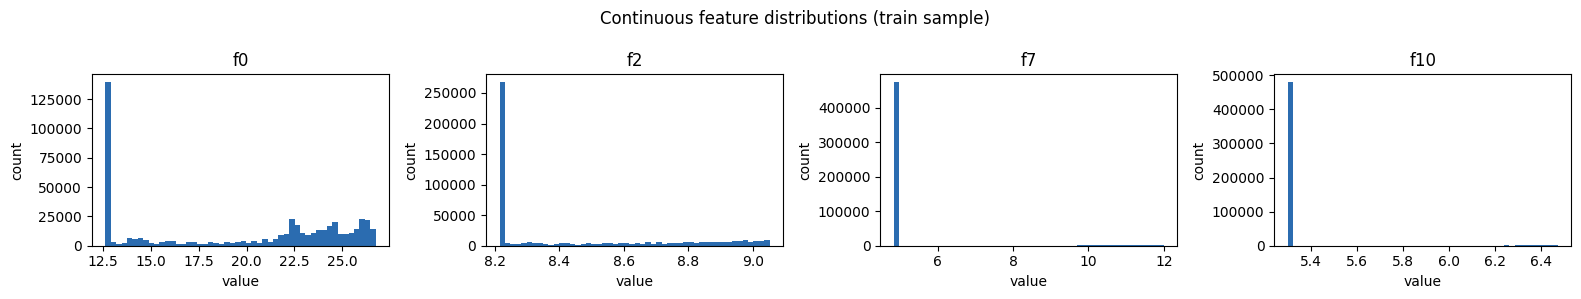

In [11]:
if RUN_STAGE in ("data", "all"):
    feature_summary = load_csv_artifact(data_dir / "feature_summary.csv")

    train_full = load_parquet(data_dir / "train.parquet")
    PLOT_SAMPLE_ROWS = min(len(train_full), 500_000)
    plot_sample = train_full.sample(n=PLOT_SAMPLE_ROWS, random_state=SEED) if PLOT_SAMPLE_ROWS < len(train_full) else train_full
    del train_full
    gc.collect()
    print(f"Plotting sample: {len(plot_sample):,} rows drawn from the train partition")

    cont_summary = feature_summary[feature_summary["kind"] == "continuous"].set_index("feature")
    display(cont_summary[["n_unique", "mean", "std", "min", "p25", "p50", "p75", "max"]].round(4))

    fig, axes = plt.subplots(1, len(CONTINUOUS_FEATURES), figsize=(4 * len(CONTINUOUS_FEATURES), 3))
    for ax, f in zip(axes, CONTINUOUS_FEATURES):
        ax.hist(plot_sample[f].astype("float64"), bins=50, color="#2b6cb0")
        ax.set_title(f)
        ax.set_xlabel("value")
        ax.set_ylabel("count")
    fig.suptitle("Continuous feature distributions (train sample)")
    fig.tight_layout()
    plt.show()


,n_unique,top_category,top_category_share
feature,,,
f1,56,10.0597,0.9877
f3,522,4.6799,0.8187
f4,233,10.2805,0.9566
f5,120,4.1155,0.9469
f6,1547,0.2944,0.2652
f8,3496,3.9719,0.5223
f9,1480,13.1901,0.7950
f11,114,-0.1687,0.9855


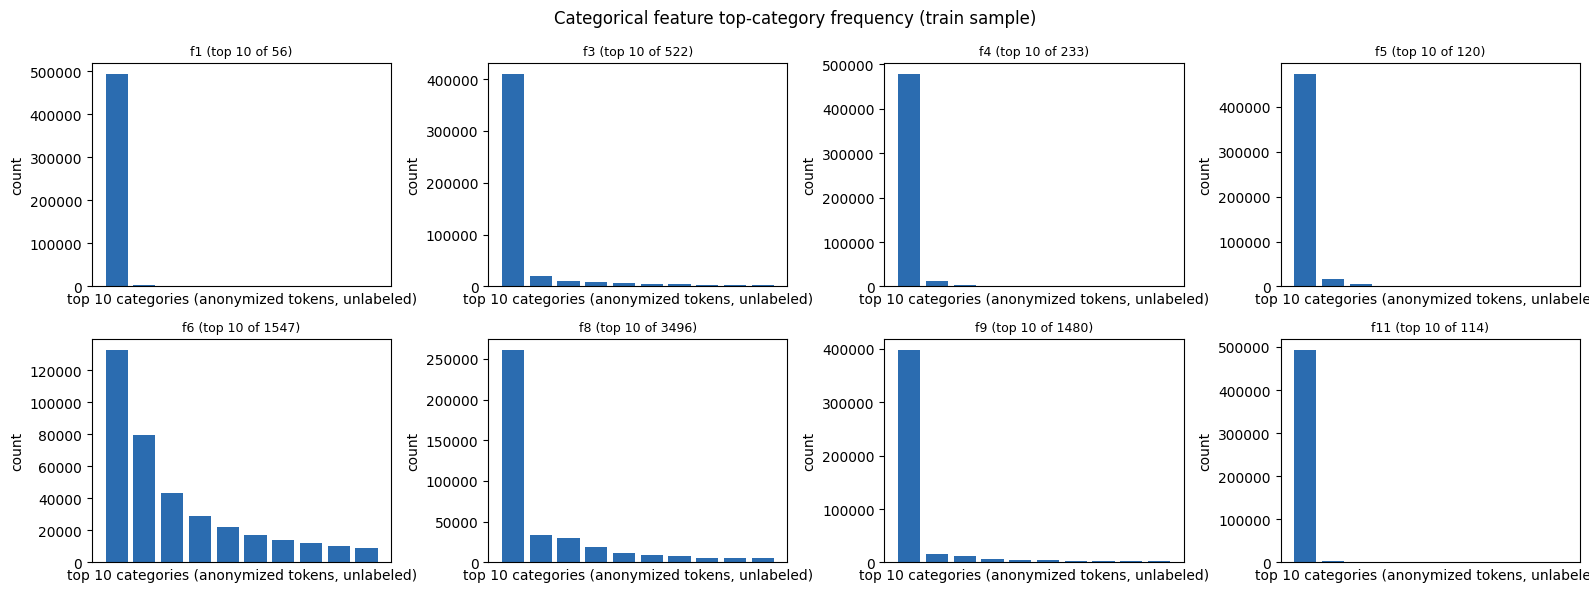

In [12]:
if RUN_STAGE in ("data", "all"):
    cat_summary = feature_summary[feature_summary["kind"] == "categorical"].set_index("feature")
    display(cat_summary[["n_unique", "top_category", "top_category_share"]].round(4))

    # x-axis tick labels are deliberately blank: these are anonymized numeric
    # tokens with no real-world meaning (see D32 above) -- the token values
    # themselves are not informative, only their relative frequency is.
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for ax, f in zip(axes.ravel(), CATEGORICAL_FEATURES):
        top = plot_sample[f].astype("float64").value_counts().head(10)
        ax.bar(range(len(top)), top.to_numpy(), color="#2b6cb0")
        ax.set_xticks([])
        ax.set_xlabel("top 10 categories (anonymized tokens, unlabeled)")
        ax.set_ylabel("count")
        ax.set_title(f"{f} (top 10 of {int(cat_summary.loc[f, 'n_unique'])})", fontsize=9)
    fig.suptitle("Categorical feature top-category frequency (train sample)")
    fig.tight_layout()
    plt.show()

    del plot_sample
    gc.collect()


**Observation.** Continuous features (histograms above) vary in shape --
some are roughly bell-shaped, others are skewed with a long tail. Categorical
features vary widely in how concentrated they are: some have a top category
holding a large share of all rows, others are more evenly spread (see
`top_category_share` in the table above).

**Interpretation.** This is why the two feature groups get different
treatment throughout this project (D32): continuous features are used as-is
(implicitly scaled by LightGBM's/Causal Forest's split-finding), while
categorical features are never treated as ordered numbers -- LightGBM uses
native categorical splits, and Causal Forest uses the frequency-capped
one-hot encoding described in Stage 4. A skewed continuous feature or a
concentrated categorical feature is not a data quality problem here, just a
property models need to be told about explicitly (which is exactly what the
D32 fix ensures).

**Limitation.** These plots use a random sample (see the row count printed
above), not the full train partition -- rare categories or distribution tails
may be under-represented visually even though the `n_unique` /
`top_category_share` table above is computed on the full partition.


## Stage 2 -- Baseline (response model)

**Why this model?** It predicts `P(Y|X)` -- who is likely to convert -- not
treatment effect. It exists purely as the non-causal comparator every uplift
model below has to beat to justify its added complexity.

A plain LightGBM binary classifier on the selected outcome (`OUTCOME_COLUMN`
-- `conversion` by default, or `visit`), ignoring treatment entirely. It is
the **non-causal comparator**: strong response-ranking performance here says
nothing about *causal* ranking quality, which is the entire point of running
it alongside the uplift models.

**Artifacts written** under `outputs/{OUTCOME_COLUMN}/baseline/` (e.g.
`outputs/conversion/baseline/`): `model.pkl`, `metrics.json`,
`predictions.parquet` (validation + test scores), `qini_curve.csv`,
`uplift_curve.csv`, `decile_table.csv`, and `roc_curve.csv` / `pr_curve.csv`
/ `calibration_curve.csv` (validation-set diagnostics -- meaningful here
because this model's output is a calibrated probability; the uplift models'
outputs are not).


In [13]:
if RUN_STAGE in ("baseline", "all"):
    BASELINE_METRICS = run_baseline_stage(CONFIG, OUTCOME_COLUMN, SEED, DATA_SIGNATURE)
    print(f"Response model ready -- validation Qini above random: {BASELINE_METRICS['val_qini_above_random']:.4f}")
else:
    print(f"Baseline stage skipped (RUN_STAGE={RUN_STAGE!r})")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[104]	valid_0's binary_logloss: 0.103756
Response model ready -- validation Qini above random: 6296.7643


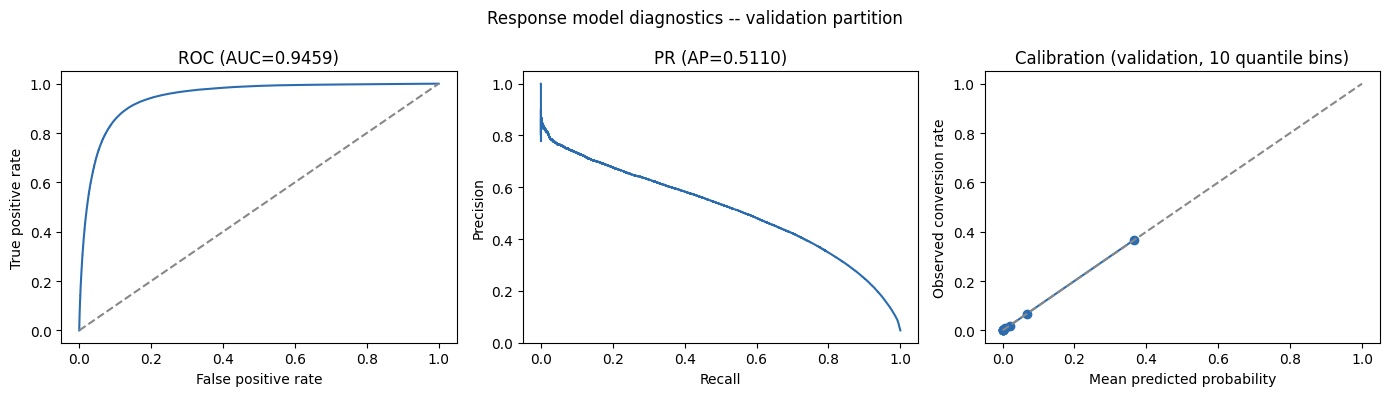

In [14]:
if RUN_STAGE in ("baseline", "all"):
    baseline_dir = stage_dir("baseline", outcome=OUTCOME_COLUMN)
    roc = load_csv_artifact(baseline_dir / "roc_curve.csv")
    pr = load_csv_artifact(baseline_dir / "pr_curve.csv")
    cal = load_csv_artifact(baseline_dir / "calibration_curve.csv")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].plot(roc["fpr"], roc["tpr"], color="#2b6cb0")
    axes[0].plot([0, 1], [0, 1], "--", color="#888888")
    axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"ROC (AUC={BASELINE_METRICS['val_roc_auc']:.4f})")

    axes[1].plot(pr["recall"], pr["precision"], color="#2b6cb0")
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"PR (AP={BASELINE_METRICS['val_average_precision']:.4f})")

    axes[2].plot(cal["mean_predicted"], cal["fraction_positive"], "o-", color="#2b6cb0")
    axes[2].plot([0, 1], [0, 1], "--", color="#888888")
    axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed conversion rate")
    axes[2].set_title("Calibration (validation, 10 quantile bins)")
    fig.suptitle("Response model diagnostics -- validation partition")
    fig.tight_layout()
    plt.show()

**Observation.** ROC/PR show reasonable separation for a response model, and
the calibration curve should track the diagonal closely if predicted
probabilities are trustworthy as probabilities.

**Interpretation.** These three plots describe one thing only: how well this
model predicts *who converts*, using validation data. That is a legitimate
and useful property (a well-calibrated model's score can be read as "X%
chance of converting"), but it is **not** a measure of uplift-ranking
quality -- a model can have excellent ROC/AUC here and still rank users by
*incremental* effect no better than random, because those are different
questions (see the glossary's "uplift" entry).

**Limitation.** Do not use these plots to judge whether the response model
"beats" the uplift models below -- that comparison only makes sense on the
Qini/AUUC metrics in Stage 5, which measure causal ranking, not response
prediction.


## Stage 3 -- Uplift models (T-Learner, X-Learner)

**Why T-Learner?** The simplest way to estimate incremental effect: fit two
independent outcome models, one on treated users and one on control users,
then take their difference -- `tau_hat(x) = mu1_hat(x) - mu0_hat(x)`.

**Why X-Learner?** Same goal, but corrects the T-Learner's main weakness:
when the treatment and control groups are different sizes (as here -- see
Stage 1), the T-Learner's two models are trained on very different amounts
of data, which biases `tau_hat`. `fit_x_learner` takes the **raw** train
frame deliberately -- it fits a *fold-local* categorical transform inside
each of its two cross-fitting folds. Passing an already-transformed frame
would leak each fold's category vocabulary into the other fold;
`fit_x_learner` raises rather than let that happen silently (a real bug this
project found and fixed -- see README's Methodology notes).

*A note on this cell's code:* unlike the other three stages, the T-Learner
and X-Learner fitting calls below stay inline in this notebook rather than
moving into `src/pipeline.py`. That's deliberate -- this is the exact call
site the fold-local leakage bug lived in, and keeping it visible here (with
`tests/test_artifacts.py` asserting the raw frame is what actually gets
passed) is a guardrail against silently reintroducing it, not an
inconsistency with the rest of this notebook's "hide the plumbing" approach.

**Artifacts written** under `outputs/{OUTCOME_COLUMN}/uplift/tlearner/` and
`outputs/{OUTCOME_COLUMN}/uplift/xlearner/`, each with the same `model.pkl` /
`metrics.json` /
`predictions.parquet` / `qini_curve.csv` / `uplift_curve.csv` /
`decile_table.csv` shape as the baseline stage.


In [15]:
def ensure_uplift_artifacts():
    uplift_dir = stage_dir("uplift", outcome=OUTCOME_COLUMN)
    tlearner_dir, xlearner_dir = uplift_dir / "tlearner", uplift_dir / "xlearner"
    cached = (
        stage_cache_hit(tlearner_dir / "metrics.json", DATA_SIGNATURE, outcome=OUTCOME_COLUMN,
                         extra_files=[tlearner_dir / "model.pkl"])
        and stage_cache_hit(xlearner_dir / "metrics.json", DATA_SIGNATURE, outcome=OUTCOME_COLUMN,
                             extra_files=[xlearner_dir / "model.pkl"])
    )
    if cached:
        return load_json(tlearner_dir / "metrics.json"), load_json(xlearner_dir / "metrics.json")

    data_dir = stage_dir("data")
    transform = get_lgbm_transform(DATA_SIGNATURE)
    train_frame = load_parquet(data_dir / "train.parquet")
    val_frame = load_parquet(data_dir / "validation.parquet")
    test_frame = load_parquet(data_dir / "test.parquet")

    X_train, X_val, X_test = (transform.transform(f) for f in (train_frame, val_frame, test_frame))
    Y_train, Y_val, Y_test = (f[OUTCOME_COLUMN] for f in (train_frame, val_frame, test_frame))
    T_train, T_val, T_test = (f[TREATMENT_COLUMN] for f in (train_frame, val_frame, test_frame))
    row_id_val, row_id_test = val_frame["row_id"], test_frame["row_id"]

    tlearner_dir.mkdir(parents=True, exist_ok=True)
    start = time.perf_counter()
    t_learner = fit_t_learner(X_train, T_train, Y_train, X_val, T_val, Y_val, seed=SEED)
    t_runtime = time.perf_counter() - start
    t_val_scores, t_test_scores = t_learner.predict_tau(X_val), t_learner.predict_tau(X_test)
    t_val_metrics = evaluate_ranking(t_val_scores, T_val, Y_val)
    t_test_metrics = evaluate_ranking(t_test_scores, T_test, Y_test)
    save_pickle(t_learner, tlearner_dir / "model.pkl")
    t_metrics = package_ranking_artifacts(
        tlearner_dir, "T-Learner", t_val_metrics, t_test_metrics,
        t_val_scores, t_test_scores, T_val, Y_val, T_test, Y_test,
        row_id_val, row_id_test, t_runtime,
        extra_metrics=experiment_metadata(OUTCOME_COLUMN, seed=SEED, data_signature=DATA_SIGNATURE),
    )

    del X_train, X_val, X_test
    gc.collect()

    xlearner_dir.mkdir(parents=True, exist_ok=True)
    start = time.perf_counter()
    # Deliberately the RAW train_frame, not a transformed X_train -- see this
    # stage's markdown above.
    x_learner = fit_x_learner(train_frame, T_train, Y_train, seed=SEED)
    x_runtime = time.perf_counter() - start
    X_val_x, X_test_x = transform.transform(val_frame), transform.transform(test_frame)
    x_val_scores, x_test_scores = x_learner.predict_tau(X_val_x), x_learner.predict_tau(X_test_x)
    x_val_metrics = evaluate_ranking(x_val_scores, T_val, Y_val)
    x_test_metrics = evaluate_ranking(x_test_scores, T_test, Y_test)
    save_pickle(x_learner, xlearner_dir / "model.pkl")
    x_metrics = package_ranking_artifacts(
        xlearner_dir, "X-Learner", x_val_metrics, x_test_metrics,
        x_val_scores, x_test_scores, T_val, Y_val, T_test, Y_test,
        row_id_val, row_id_test, x_runtime,
        extra_metrics=experiment_metadata(OUTCOME_COLUMN, seed=SEED, data_signature=DATA_SIGNATURE),
    )

    del train_frame, val_frame, test_frame, X_val_x, X_test_x
    gc.collect()
    return t_metrics, x_metrics


if RUN_STAGE in ("uplift", "all"):
    TLEARNER_METRICS, XLEARNER_METRICS = ensure_uplift_artifacts()
    print(f"T-Learner validation Qini above random: {TLEARNER_METRICS['val_qini_above_random']:.4f}")
    print(f"X-Learner validation Qini above random: {XLEARNER_METRICS['val_qini_above_random']:.4f}")
else:
    print(f"Uplift stage skipped (RUN_STAGE={RUN_STAGE!r})")


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[102]	valid_0's binary_logloss: 0.106041
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[46]	valid_0's binary_logloss: 0.0907435
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[70]	valid_0's binary_logloss: 0.106259
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[41]	valid_0's binary_logloss: 0.0923491
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[80]	valid_0's binary_logloss: 0.105843
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[40]	valid_0's binary_logloss: 0.09203
T-Learner validation Qini above random: 4840.8585
X-Learner validation Qini above random: 5682.4657


## Stage 4 -- Causal Forest

**Why this model?** The three estimators above all predict treatment effect
*indirectly* -- by differencing or regressing outcome models. Causal Forest
estimates it *directly*: it grows an "honest" random forest (see the
glossary above) whose splits are chosen specifically to separate users with
different treatment effects, rather than differencing two separately-fit
models.

`econml.grf.CausalForest` has no native categorical support and consumes a
dense numeric matrix, so categorical features go through
`CausalForestCategoricalEncoder`: **frequency-capped top-K one-hot**, with an
`OTHER` bucket for the tail and for categories unseen at train time. Raw
integer tokens would fabricate a false ordering the forest's splits would
exploit -- `fit_causal_forest` rejects that outright.

**This is the slow, memory-heavy stage** (`n_jobs=1`, required for
reproducible predictions). The encoded train matrix is built, fit, and freed
before the validation/test matrices are ever built -- at most one CF-encoded
partition exists in memory at a time. `K = configs/config.yaml:
causal_forest.categorical_top_k` (shipped default `8`) is a resource-ladder
choice, not a free parameter -- see README's Methodology notes for why `K=32`
risks ~21GB for the encoded train matrix alone at full CRITEO scale.

**Artifacts written** under `outputs/{OUTCOME_COLUMN}/causal_forest/`: the usual
`model.pkl` / `metrics.json` / prediction and curve files, plus
`resource_evidence.json` recording the actual `K`, encoded column count, and
an estimated encoded-matrix size -- the resource-gate evidence for whichever
`K` this run actually used.


In [16]:
if RUN_STAGE in ("causal_forest", "all"):
    if RUN_CAUSAL_FOREST:
        CAUSAL_FOREST_METRICS = run_causal_forest_stage(CONFIG, OUTCOME_COLUMN, SEED, DATA_SIGNATURE)
        print(f"Causal Forest ready -- validation Qini above random: {CAUSAL_FOREST_METRICS['val_qini_above_random']:.4f}")
    else:
        CAUSAL_FOREST_METRICS = None
        print("Causal Forest skipped (RUN_CAUSAL_FOREST = False)")
else:
    print(f"Causal Forest stage skipped (RUN_STAGE={RUN_STAGE!r})")


Causal Forest ready -- validation Qini above random: 6598.0319


In [17]:
if RUN_STAGE in ("causal_forest", "all") and RUN_CAUSAL_FOREST:
    # Reader-facing summary of this evidence (K, encoded column count) is
    # reported as prose in the Causal Forest interpretation section of
    # Stage 5's report -- this cell is the raw developer-facing detail
    # behind it (memory/runtime accounting), shown only in DEBUG mode.
    resource_evidence = load_json(stage_dir("causal_forest", outcome=OUTCOME_COLUMN) / "resource_evidence.json")
    gb = resource_evidence["estimated_encoded_matrix_bytes"] / 1024**3
    debug_print(f"K (categorical_top_k)   : {resource_evidence['categorical_top_k']}")
    debug_print(f"Encoded feature count   : {resource_evidence['encoded_feature_count']}")
    debug_print(f"Train rows encoded      : {resource_evidence['n_train_rows']:,}")
    debug_print(f"Estimated encoded matrix: {gb:.3f} GB ({resource_evidence['dtype']}, before CausalForest's own fit-time overhead)")
    debug_print(f"n_estimators={resource_evidence['n_estimators']}  max_depth={resource_evidence['max_depth']}  "
                f"max_features={resource_evidence['max_features']}  honest={resource_evidence['honest']}  "
                f"n_jobs={resource_evidence['n_jobs']}  runtime={resource_evidence['runtime_seconds']:.1f}s")


## Stage 5 -- Final report

**Fits nothing.** Every cell below reads only the artifacts each earlier
stage saved under `outputs/` -- this is the stage to run (`RUN_STAGE =
"report"`) after a kernel restart to see the full comparison without
retraining anything. Whichever of the four models were actually run appear
below; a model whose stage was skipped or never run is shown as unavailable,
never fabricated.

Everything is scored on the **test** partition -- never fit on, early-stopped
against, or used for selection. A random ranking is included as the honest
floor: an uplift model that cannot beat it has not earned its complexity.

**Reading the table below.**

- **`qini_above_random`** -- the primary metric; look here first. How much
  better this model's ranking is at capturing incremental conversions than a
  random ranking, on the same scale as the Qini curve plotted further down.
- `auuc_above_random` -- a second, differently-weighted view of the same
  ranking quality (cross-check: if it agrees with `qini_above_random` on the
  ranking of models, that ranking is more trustworthy).
- `qini_area` / `auuc_area` -- the same two curves' raw area, *not* relative
  to random. Useful for comparing this run against a different run of the
  same model, less useful for judging one run in isolation.
- `uplift@10pct` / `@20pct` / ... -- a concrete, business-facing slice of the
  same ranking: the observed incremental conversion rate if only the top K%
  of users by predicted effect were targeted.

See the glossary near the top of this notebook for what each of these
measures conceptually.


In [18]:
if RUN_STAGE in ("report", "all"):
    MODEL_STAGE_DIRS = {
        "Response LightGBM": stage_dir("baseline", outcome=OUTCOME_COLUMN),
        "T-Learner": stage_dir("uplift", outcome=OUTCOME_COLUMN) / "tlearner",
        "X-Learner": stage_dir("uplift", outcome=OUTCOME_COLUMN) / "xlearner",
        "Causal Forest": stage_dir("causal_forest", outcome=OUTCOME_COLUMN),
    }
    available = {label: d for label, d in MODEL_STAGE_DIRS.items() if (d / "metrics.json").is_file()}
    print("Available model artifacts:", list(available) or "NONE")
    if not available:
        raise RuntimeError(
            "No model artifacts found under outputs/. Run RUN_STAGE in "
            "{'baseline', 'uplift', 'causal_forest', 'all'} at least once first."
        )

    figures_dir = stage_dir("report", outcome=OUTCOME_COLUMN) / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    reference_label = next(iter(available))
    reference_predictions = load_parquet(available[reference_label] / "predictions.parquet")
    test_ref = reference_predictions[reference_predictions["partition"] == "test"].sort_values("row_id")
    T_test_ref, Y_test_ref = test_ref["treatment"].to_numpy(), test_ref["outcome"].to_numpy()
    rng = np.random.default_rng(SEED)
    random_metrics = evaluate_ranking(rng.uniform(size=len(T_test_ref)), T_test_ref, Y_test_ref)

    comparison = build_model_comparison_table(available, random_metrics)
    save_csv(comparison.reset_index(), stage_dir("report", outcome=OUTCOME_COLUMN) / "model_comparison.csv")
    display(comparison.round(5))

    # reference_predictions/test_ref (up to ~n_val+n_test rows) are only
    # needed to derive T_test_ref/Y_test_ref/random_metrics above -- no
    # later cell references the frames themselves.
    del reference_predictions, test_ref
    gc.collect()


Available model artifacts: ['Response LightGBM', 'T-Learner', 'X-Learner', 'Causal Forest']


,objective,auuc_above_random,qini_above_random,auuc_area,qini_area,uplift@10pct,uplift@20pct,uplift@30pct,uplift@50pct,uplift@100pct
model,,,,,,,,,,
Causal Forest,tau(X) — CATE estimation,7746.51869,6642.20308,18229.91600,15553.09504,0.06052,0.03858,0.02878,0.01915,0.01
Response LightGBM,P(Y|X) — naive targeting baseline,7280.11699,6226.73464,17763.51429,15137.62660,0.05219,0.03796,0.02845,0.01908,0.01
X-Learner,tau(X) — CATE estimation,6723.06476,5759.00153,17206.46207,14669.89349,0.05499,0.03743,0.02799,0.01812,0.01
T-Learner,tau(X) — CATE estimation,6591.46614,5653.94009,17074.86344,14564.83205,0.05592,0.03706,0.02753,0.01776,0.01
Random (reference),Uninformative random ranking,219.92898,186.67452,10703.32628,9097.56648,0.00976,0.00988,0.01041,0.01011,0.01


**Observation.** The table above ranks every model that has been run so far
by `qini_above_random`, alongside a random-targeting reference row.

**Interpretation.** A model above the random reference has a ranking that
beats guessing; a model near it has learned little that a random targeting
policy wouldn't already achieve. The gap between the top model and the
runner-up is checked for statistical significance just below -- a higher
point estimate here is not, by itself, evidence that one model is truly
better (see the "paired bootstrap" glossary entry).

**Limitation.** This table only shows models whose stage has actually been
run (`RUN_STAGE`/`RUN_CAUSAL_FOREST`) -- a missing row means "not run yet,"
never "ran and failed."


In [19]:
if RUN_STAGE in ("report", "all"):
    causal_models = [m for m in ("T-Learner", "X-Learner", "Causal Forest") if m in available]
    ranked = comparison.drop(index="Random (reference)", errors="ignore")
    best = ranked.index[0]
    beat_random = [m for m in ranked.index if ranked.loc[m, "qini_above_random"] > random_metrics.qini_above_random]

    print("BEST MODEL (by point estimate):", best)
    print(f"  Qini above random : {ranked.loc[best, 'qini_above_random']:.5f}")
    print(f"  AUUC above random : {ranked.loc[best, 'auuc_above_random']:.5f}")
    print(f"  uplift@10pct      : {ranked.loc[best, 'uplift@10pct']}")
    print()
    print("Models beating the random reference:", beat_random or "NONE")

    # A higher point estimate alone does not establish superiority -- check
    # whether the gap to the runner-up survives resampling noise (see the
    # glossary's "paired bootstrap" entry) before calling `best` the winner.
    if len(ranked.index) > 1:
        runner_up = ranked.index[1]

        def _test_scores(label):
            p = load_parquet(available[label] / "predictions.parquet")
            p = p[p["partition"] == "test"].sort_values("row_id")
            return p["score"].to_numpy(dtype=np.float64)

        N_BOOT_TOP2 = 500
        boot = paired_bootstrap_gaps(
            _test_scores(best), _test_scores(runner_up), T_test_ref, Y_test_ref, seed=SEED, n_boot=N_BOOT_TOP2,
            metrics={"qini_above_random": lambda m: m.qini_above_random},
        )["qini_above_random"]
        significant = boot["excludes_zero"]
        print()
        print(f"Paired bootstrap ({N_BOOT_TOP2} resamples): {best} vs {runner_up}, "
              f"Qini-above-random gap 95% CI = [{boot['ci_low']:.4f}, {boot['ci_high']:.4f}]")
        if significant:
            print(f"  -> gap is statistically distinguishable from resampling noise at this sample size.")
        else:
            print(f"  -> gap is NOT statistically distinguishable from resampling noise at this sample "
                  f"size -- {best} should not be reported as definitively superior to {runner_up} on this basis alone.")


BEST MODEL (by point estimate): Causal Forest
  Qini above random : 6642.20308
  AUUC above random : 7746.51869
  uplift@10pct      : 0.060520283909396316

Models beating the random reference: ['Causal Forest', 'Response LightGBM', 'X-Learner', 'T-Learner']

Paired bootstrap (500 resamples): Causal Forest vs Response LightGBM, Qini-above-random gap 95% CI = [252.3045, 596.5269]
  -> gap is statistically distinguishable from resampling noise at this sample size.


**Observation.** The printed 95% confidence interval either excludes zero
(the gap is unlikely to be resampling noise) or includes zero (the data
cannot rule out "no real difference" between the top two models).

**Interpretation.** This is the single most important check in this
notebook. A point-estimate leaderboard alone (the table above) always
produces a "winner" by construction, even when two models are statistically
indistinguishable -- the bootstrap is what separates "this model happened to
score higher on this test set" from "this model is actually better."

**Limitation.** This bootstrap only tests the gap between the *top two*
models on *one* metric (`qini_above_random`). It does not test every
pairwise combination of models and metrics -- see the Limitations section at
the end of this notebook.


### Uplift visualization

The curves below show the full ranking, not just the single-number summary
in the table above -- a model can lead on Qini-above-random while still
crossing below another model (or the random reference) over part of the
coverage range, which the table alone would hide.

In [20]:
def sample_for_plot(df: pd.DataFrame, max_points: int = 5000) -> pd.DataFrame:
    '''Evenly-spaced subsample of a (roughly monotonic) curve for
    plotting only -- never used for a metric or artifact. Qini/uplift
    curves are one row per test-set row (up to ~2M+ at full CRITEO scale),
    far more vertices than a rendered figure can show distinct pixels for,
    and what made this section slow to render. np.linspace-based even
    sampling preserves the curve's shape and always keeps both endpoints
    (coverage 0 and 1), which anchor how the curve is read.'''

    if len(df) <= max_points:
        return df
    idx = np.linspace(0, len(df) - 1, max_points, dtype=int)
    return df.iloc[idx]


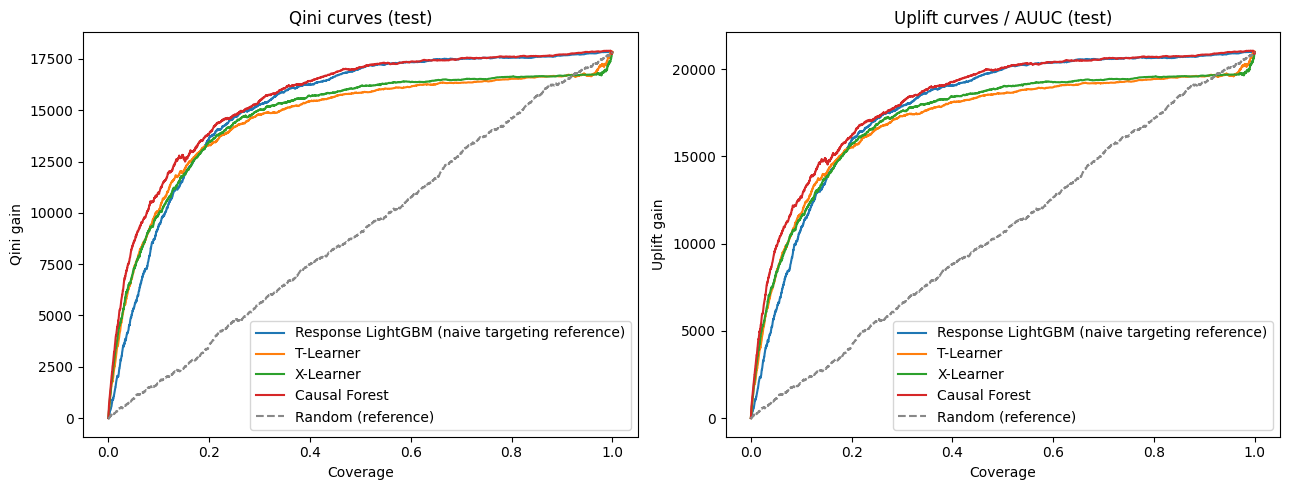

In [21]:
if RUN_STAGE in ("report", "all"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    for label, d in available.items():
        qc, uc = load_csv_artifact(d / "qini_curve.csv"), load_csv_artifact(d / "uplift_curve.csv")
        plot_label = "Response LightGBM (naive targeting reference)" if label == "Response LightGBM" else label
        qc_plot, uc_plot = sample_for_plot(qc), sample_for_plot(uc)
        ax1.plot(qc_plot["coverage"], qc_plot["qini_gain"], label=plot_label)
        ax2.plot(uc_plot["coverage"], uc_plot["uplift_gain"], label=plot_label)
    random_qini_plot = sample_for_plot(random_metrics.qini_curve)
    random_uplift_plot = sample_for_plot(random_metrics.uplift_curve)
    ax1.plot(random_qini_plot["coverage"], random_qini_plot["qini_gain"],
              "--", color="#888888", label="Random (reference)")
    ax2.plot(random_uplift_plot["coverage"], random_uplift_plot["uplift_gain"],
              "--", color="#888888", label="Random (reference)")
    ax1.set_xlabel("Coverage"); ax1.set_ylabel("Qini gain"); ax1.set_title("Qini curves (test)"); ax1.legend()
    ax2.set_xlabel("Coverage"); ax2.set_ylabel("Uplift gain"); ax2.set_title("Uplift curves / AUUC (test)"); ax2.legend()
    fig.tight_layout()
    fig.savefig(figures_dir / "qini_uplift_curves.png", dpi=120)
    plt.show()
    plt.close(fig)


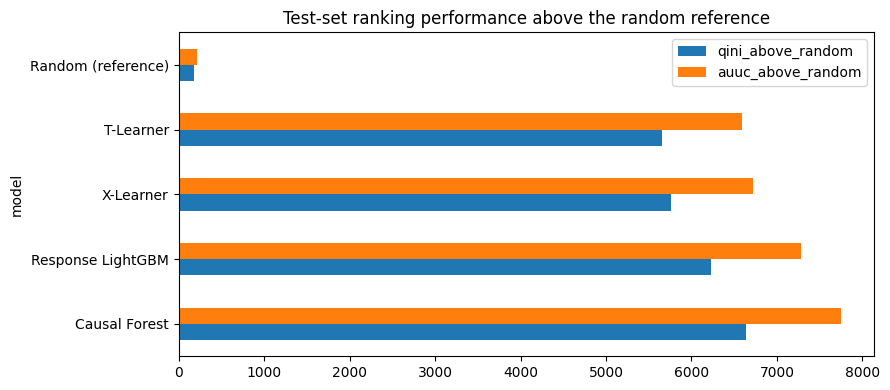

In [22]:
if RUN_STAGE in ("report", "all"):
    fig, ax = plt.subplots(figsize=(9, 4))
    comparison[["qini_above_random", "auuc_above_random"]].plot.barh(
        ax=ax, title="Test-set ranking performance above the random reference"
    )
    fig.tight_layout()
    fig.savefig(figures_dir / "comparison_barh.png", dpi=120)
    plt.show()
    plt.close(fig)


**Observation.** The Qini/uplift curves show each model's full ranking
across every coverage level, not just the single point-estimate summarized
in the table above; the bar chart makes the `qini_above_random` /
`auuc_above_random` ranking easier to compare at a glance.

**Interpretation.** A model whose curve sits consistently above the others
(and above the dashed random-reference line) is capturing more incremental
conversions at every targeting budget, not just on average. A curve that
crosses another partway through means the "better" model depends on how much
of the population you can afford to target -- information the single-number
table above cannot show.

**Limitation.** These are test-set curves from one seeded split -- see the
paired bootstrap above for whether the *gap* between curves at the
`qini_above_random` summary level is statistically meaningful.


### Treatment effect distribution

A model whose predicted effect is nearly constant is not finding heterogeneity, whatever its Qini says.

,count,mean,std,min,5%,25%,50%,75%,95%,max
T-Learner,2096939.0,0.007346,0.030175,-0.391853,-0.002645,-0.000314,0.000104,0.002036,0.053136,0.546646
X-Learner,2096939.0,0.007214,0.026087,-0.333425,0.000582,0.000595,0.001336,0.001844,0.042901,0.500740
Causal Forest,2096939.0,0.009275,0.016223,-0.029848,0.002423,0.002706,0.004439,0.006673,0.041570,0.177979


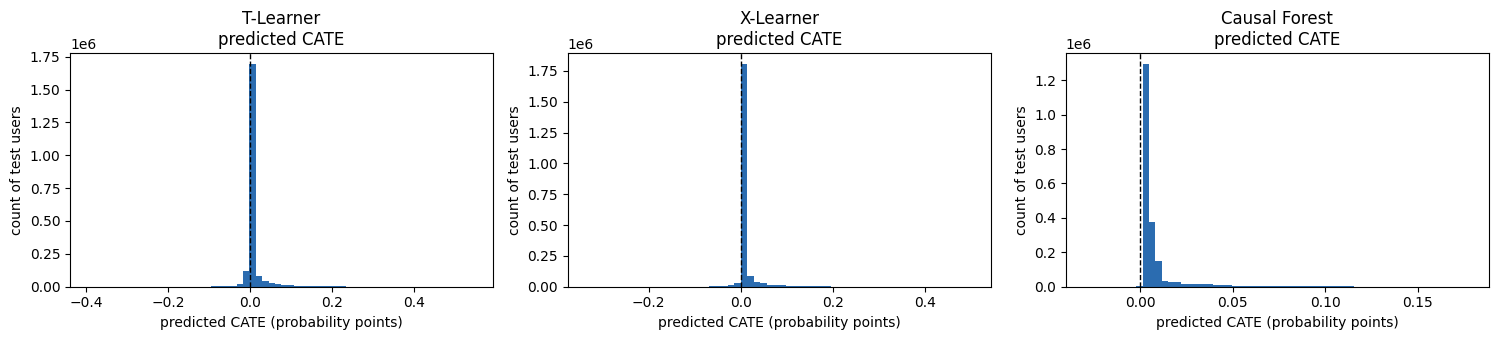

In [23]:
if RUN_STAGE in ("report", "all"):
    if causal_models:
        cate = pd.DataFrame({
            label: load_parquet(available[label] / "predictions.parquet")
                .pipe(lambda f: f[f["partition"] == "test"].sort_values("row_id"))["score"].to_numpy()
            for label in causal_models
        })
        display(cate.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T.round(6))

        fig, axes = plt.subplots(1, len(causal_models), figsize=(5 * len(causal_models), 3.5), squeeze=False)
        for ax, label in zip(axes[0], causal_models):
            ax.hist(cate[label], bins=60, color="#2b6cb0")
            ax.axvline(0.0, color="k", linestyle="--", linewidth=1)
            ax.set_title(f"{label}\npredicted CATE")
            ax.set_xlabel("predicted CATE (probability points)")
            ax.set_ylabel("count of test users")
        fig.tight_layout()
        fig.savefig(figures_dir / "cate_distribution.png", dpi=120)
        plt.show()
        plt.close(fig)
    else:
        print("No causal model (T-Learner / X-Learner / Causal Forest) artifacts available yet.")


**Observation.** The dashed line marks zero predicted effect. A model
finding real heterogeneity should show meaningful spread on both sides of
it, not a narrow spike.

**Interpretation.** A near-constant predicted CATE (a tall, narrow spike)
means the model is effectively predicting "everyone gets roughly the same
effect," which defeats the purpose of uplift modeling -- you would target
the same way regardless of `x`. Real spread (some users clearly positive,
some near zero, possibly some negative) is what makes *ranking by predicted
effect* a meaningfully different strategy than targeting everyone or no one.

**Limitation.** Spread alone does not prove the spread is *accurate* --
both potential outcomes are never observed for the same user, so there is no
ground truth to validate an individual prediction against (see the
Limitations section at the end of this notebook).


### Uplift decile analysis

If a ranking is real, observed uplift should decline from decile 1 (highest predicted) downward.

,T-Learner,X-Learner,Causal Forest
decile,,,
1,0.05592,0.05499,0.06052
2,0.00847,0.01233,0.00937
3,0.00261,0.00380,0.00251
4,0.00069,0.00098,0.00165
5,0.00057,0.00025,0.00058
6,0.00045,0.00015,0.00021
7,0.00039,0.00024,0.00020
8,0.00029,0.00014,0.00041
9,0.00007,0.00026,0.00020


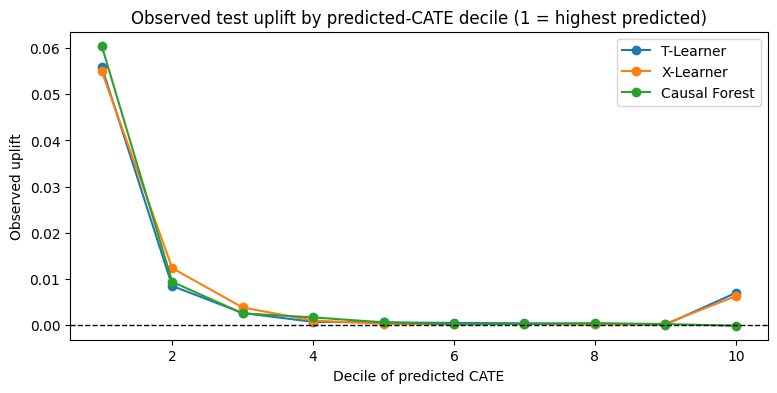

Spearman rank correlation between causal models' predicted CATE:
               T-Learner  X-Learner  Causal Forest
T-Learner          1.000      0.596          0.610
X-Learner          0.596      1.000          0.781
Causal Forest      0.610      0.781          1.000


In [24]:
if RUN_STAGE in ("report", "all") and causal_models:
    deciles = pd.DataFrame({
        label: load_csv_artifact(available[label] / "decile_table.csv").set_index("decile")["observed_uplift"]
        for label in causal_models
    })
    display(deciles.round(5))

    ax = deciles.plot(marker="o", figsize=(9, 4),
                       title="Observed test uplift by predicted-CATE decile (1 = highest predicted)")
    ax.axhline(0.0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel("Decile of predicted CATE"); ax.set_ylabel("Observed uplift")
    ax.figure.savefig(figures_dir / "uplift_deciles.png", dpi=120)
    plt.show()
    plt.close(ax.figure)

    if len(causal_models) > 1:
        print("Spearman rank correlation between causal models' predicted CATE:")
        print(cate.corr(method="spearman").round(3))


**Observation.** Observed test-set uplift should decline roughly
monotonically from decile 1 (highest predicted effect) to decile 10 (lowest)
if the ranking is real. The Spearman correlation above shows how much the
different causal models agree on *who* to target, independent of the exact
predicted values.

**Interpretation.** A roughly declining staircase is direct evidence the
model's ranking reflects something real in the test data, not an artifact of
the training process -- a stronger, more concrete check than the
single-number Qini/AUUC summary, because it is visible decile-by-decile. High
Spearman correlation between differently-specified estimators (e.g. X-Learner
vs. Causal Forest) is reassuring convergent validity: models built on
different assumptions agreeing on who to target is harder to get by chance
than one model agreeing with itself.

**Limitation.** A noisy or non-monotonic staircase in the bottom deciles is
common and not necessarily disqualifying -- the deciles with the fewest
positive outcomes (rare event, small per-decile sample) are the least
statistically reliable ones.


### Response model diagnostics (ROC / PR / calibration)

Reproduced here from the baseline stage's saved artifacts so the report stage stays self-contained after a kernel restart.

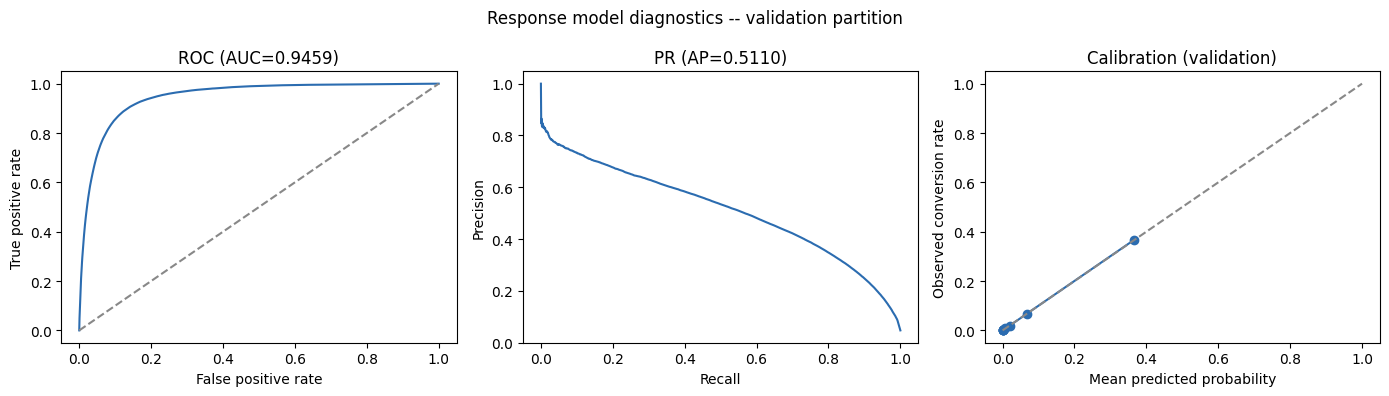

In [25]:
if RUN_STAGE in ("report", "all"):
    if "Response LightGBM" in available:
        baseline_dir = available["Response LightGBM"]
        roc = load_csv_artifact(baseline_dir / "roc_curve.csv")
        pr = load_csv_artifact(baseline_dir / "pr_curve.csv")
        cal = load_csv_artifact(baseline_dir / "calibration_curve.csv")
        baseline_metrics = load_json(baseline_dir / "metrics.json")
        # roc/pr can in the worst case carry one row per unique predicted
        # score (up to O(n_validation)); sample_for_plot is a no-op when
        # they're already small, so this is a defensive guard, not a
        # behavior change for the common case.
        roc_plot, pr_plot = sample_for_plot(roc), sample_for_plot(pr)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].plot(roc_plot["fpr"], roc_plot["tpr"], color="#2b6cb0")
        axes[0].plot([0, 1], [0, 1], "--", color="#888888")
        axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
        axes[0].set_title(f"ROC (AUC={baseline_metrics['val_roc_auc']:.4f})")
        axes[1].plot(pr_plot["recall"], pr_plot["precision"], color="#2b6cb0")
        axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
        axes[1].set_title(f"PR (AP={baseline_metrics['val_average_precision']:.4f})")
        axes[2].plot(cal["mean_predicted"], cal["fraction_positive"], "o-", color="#2b6cb0")
        axes[2].plot([0, 1], [0, 1], "--", color="#888888")
        axes[2].set_xlabel("Mean predicted probability"); axes[2].set_ylabel("Observed conversion rate")
        axes[2].set_title("Calibration (validation)")
        fig.suptitle("Response model diagnostics -- validation partition")
        fig.tight_layout()
        fig.savefig(figures_dir / "baseline_diagnostics.png", dpi=120)
        plt.show()
        plt.close(fig)
    else:
        print("Response model artifacts not available.")


Same response-model-only caveat as Stage 2: these diagnostics measure
predictive quality of `P(Y|X)`, not causal ranking quality (see the
interpretation after Stage 2's version of this figure for the full
explanation).


## Causal Forest interpretation

Causal Forest gets its own pass because its `K=8` categorical encoding is a
memory/runtime tradeoff, not a performance choice (see Stage 4) -- worth
checking its predicted-CATE spread and decile behavior on its own before
comparing it to the other estimators above.

In [26]:
if RUN_STAGE in ("report", "all"):
    if "Causal Forest" in available:
        cf_metrics = load_json(available["Causal Forest"] / "metrics.json")
        cf_deciles = load_csv_artifact(available["Causal Forest"] / "decile_table.csv").sort_values("decile")
        cf_resource = load_json(stage_dir("causal_forest", outcome=OUTCOME_COLUMN) / "resource_evidence.json")
        cf_cate = cate["Causal Forest"]
        top_decile, bottom_decile = cf_deciles.iloc[0], cf_deciles.iloc[-1]

        print(f"Test qini_above_random  : {cf_metrics['test_qini_above_random']:.5f}")
        print(f"Mean / median predicted CATE : {cf_cate.mean():.6f} / {cf_cate.median():.6f}")
        print(f"Share of rows with predicted CATE > 0 : {(cf_cate > 0).mean():.3%}")
        print(f"Top decile (highest predicted) observed uplift    : {top_decile['observed_uplift']:.5f}  (n={int(top_decile['n'])})")
        print(f"Bottom decile (lowest predicted) observed uplift  : {bottom_decile['observed_uplift']:.5f}  (n={int(bottom_decile['n'])})")
        print(f"Categorical representation: K={cf_resource['categorical_top_k']} -> "
              f"{cf_resource['encoded_feature_count']} encoded columns -- coarser than the other estimators' "
              "full-cardinality LightGBM categorical splits (see README's Methodology notes).")

        # `cate` (built in the CATE-distribution cell above, up to 4 columns
        # x ~n_test rows) is not referenced by any later cell -- release it
        # at its last use.
        del cate
        gc.collect()
    else:
        print(
            "Not available -- Causal Forest resource gate/model execution is pending. "
            "Set RUN_CAUSAL_FOREST = True, RUN_STAGE in {'causal_forest', 'all'}, and re-run."
        )


Test qini_above_random  : 6642.20308
Mean / median predicted CATE : 0.009275 / 0.004439
Share of rows with predicted CATE > 0 : 99.859%
Top decile (highest predicted) observed uplift    : 0.06052  (n=209694)
Bottom decile (lowest predicted) observed uplift  : -0.00015  (n=209693)
Categorical representation: K=8 -> 76 encoded columns -- coarser than the other estimators' full-cardinality LightGBM categorical splits (see README's Methodology notes).


## Scope

This notebook evaluates the `visit` outcome only -- see Stage 5's
comparison table, Qini/uplift curves, CATE distribution, decile analysis,
and paired bootstrap above for the complete within-outcome result.

`conversion` -- the primary, business-relevant outcome -- is evaluated
independently in `conversion_experiment.ipynb`, writing to its own
`outputs/conversion/...` artifact tree (`src/artifacts.py`'s
`OUTCOME_SCOPED_STAGES` keeps the two from ever colliding on disk). A
cross-outcome comparison -- reading both `outputs/conversion/` and
`outputs/visit/` together -- belongs in a dedicated, reader-facing report
notebook, not in either single-outcome experiment notebook, so it is not
repeated here.

In [34]:
if RUN_STAGE in ("report", "all"):
    print("=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    best_objective = (
        "P(Y|X) -- naive targeting baseline" if best == "Response LightGBM"
        else "tau(X) -- CATE estimation"
    )
    print(f"Highest point estimate : {best}  ({best_objective})")
    print(f"  Qini above random    : {ranked.loc[best, 'qini_above_random']:.5f}")
    print(f"  AUUC above random    : {ranked.loc[best, 'auuc_above_random']:.5f}")
    print(f"  uplift@10pct         : {ranked.loc[best, 'uplift@10pct']}")
    if len(ranked.index) > 1:
        significance_note = (
            "statistically significant" if significant
            else "NOT statistically significant (95% CI includes zero) -- see paired bootstrap above"
        )
        print(f"  vs. runner-up ({runner_up}), paired bootstrap: {significance_note}")
    print(f"Models beating random  : {beat_random or 'NONE'}")
    print(f"Models evaluated       : {list(available)}")
    missing = [m for m in MODEL_STAGE_DIRS if m not in available]
    print(f"Models not yet run     : {missing or 'none'}")

    print()
    print("Analysis completed.")
    print()
    print("Models evaluated:")
    for _m in available:
        print(f"  - {_m}")
    print()
    print(f"Primary outcome: {OUTCOME_COLUMN}")
    print("Evaluation: AUUC / Qini uplift ranking")
    print("Artifacts: Generated successfully")


FINAL SUMMARY
Highest point estimate : Causal Forest  (tau(X) -- CATE estimation)
  Qini above random    : 6642.20308
  AUUC above random    : 7746.51869
  uplift@10pct         : 0.060520283909396316
  vs. runner-up (Response LightGBM), paired bootstrap: statistically significant
Models beating random  : ['Causal Forest', 'Response LightGBM', 'X-Learner', 'T-Learner']
Models evaluated       : ['Response LightGBM', 'T-Learner', 'X-Learner', 'Causal Forest']
Models not yet run     : none

Analysis completed.

Models evaluated:
  - Response LightGBM
  - T-Learner
  - X-Learner
  - Causal Forest

Primary outcome: visit
Evaluation: AUUC / Qini uplift ranking
Artifacts: Generated successfully
